# Replicating Bebchuk, Cremers & Peyer (2011): The CEO Pay Slice
### U.S.E. Finance Data Hub / WRDS Database: **ExecuComp**

**Paper replicated:** [Bebchuk, L. A., Cremers, K. J. M. & Peyer, U. C. (2011). The CEO Pay Slice. *Journal of Financial Economics*, 102(1), 199–221.](https://doi.org/10.1016/j.jfineco.2011.05.006)

**Database used:** [ExecuComp](https://wrds-www.wharton.upenn.edu/pages/get-data/compustat-capital-iq-standard-poors/compustat/execucomp/) ([Data Hub guide](https://uufinance.github.io/data/wrds/databases/execucomp/))

---

## What this notebook does

Bebchuk, Cremers & Peyer (2011) introduce the "CEO Pay Slice" (CPS), defined as the fraction of the aggregate compensation of a firm's top five executives that is captured by the CEO. They show that a higher CPS is associated with lower firm value (industry-adjusted Tobin's Q), worse accounting performance, and weaker corporate governance. The paper has been cited over 1,400 times and CPS has become a standard measure of CEO dominance in the governance literature.

The beauty of this paper for a database tutorial is that the entire analysis can be done within a single ExecuComp query. All the compensation variables needed live in the `anncomp` table.

1. Pull executive-level compensation data from **ExecuComp** (`comp_execucomp.anncomp`) via the WRDS API
2. Identify the CEO and the top-5 paid executives for each firm-year
3. Construct the CEO Pay Slice (CPS) as the CEO's share of top-5 total compensation
4. Visualize the distribution and time trend of CPS across S&P 1500 firms
5. Compare our findings to the published 2011 results

## Learning objectives
- Practice connecting to WRDS and querying executive compensation data from ExecuComp
- Understand the structure of the `anncomp` table and key variables like `tdc1`, `ceoann`, and `execid`
- Learn how to aggregate executive-level data to the firm-year level
- Build intuition for how CEO compensation is structured and measured in empirical governance research

## Requirements to run this notebook
- A valid **WRDS account** with ExecuComp access (ask the Finance Data Hub if you don't have one yet)
- `pip install wrds pandas numpy matplotlib seaborn`
- You will be prompted for your WRDS username/password the first time you connect (or set up a `.pgpass` file, see the [WRDS Python guide](https://uufinance.github.io/data/wrds/notebook/))


## 1. Setup and WRDS connection

In [1]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)

db = wrds.Connection()

Enter your WRDS username [antho]:sunho2000
Enter your password:········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: n
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


## 2. Identifying the ExecuComp variables we need

All variables come from the **`comp_execucomp.anncomp`** table (Annual Compensation), which is the main table in ExecuComp. Each row represents one executive in one firm in one fiscal year.

| Paper concept | Description | ExecuComp field |
|---|---|---|
| Total Compensation | Total compensation (salary + bonus + stock awards + option awards + non-equity incentive + pension change + other) | `tdc1` |
| CEO Flag | Whether the executive served as CEO during the fiscal year | `ceoann` |
| Executive ID | Unique executive identifier | `execid` |
| Company ID | Compustat firm identifier | `gvkey` |
| Fiscal Year | Fiscal year | `year` |
| Company Name | Company name | `coname` |
| Executive Name | Full name of executive | `exec_fullname` |
| Title | Executive title | `title` |

The variable `tdc1` is the standard total compensation measure used in the literature. It is calculated by S&P and includes salary, bonus, the grant-date fair value of stock and option awards, non-equity incentive plan compensation, the change in pension value, and all other compensation. The `ceoann` field takes the value `'CEO'` if the executive served as CEO during the fiscal year.


In [2]:
# Pull all executive compensation records for the analysis period.
# We need all top executives (not just CEOs) to compute CPS.
query = """
    SELECT gvkey, year, execid, exec_fullname, coname, title,
           ceoann, tdc1
    FROM comp_execucomp.anncomp
    WHERE year BETWEEN 2006 AND 2023
      AND tdc1 IS NOT NULL
"""

df = db.raw_sql(query)
print(f"Rows pulled: {len(df):,}")
print(f"Unique firms: {df['gvkey'].nunique():,}")
df.head()

Rows pulled: 199,356
Unique firms: 3,134


,gvkey,year,execid,exec_fullname,coname,title,ceoann,tdc1
0,001004,2006.0,09249,David P. Storch,AAR CORP,Chairman & CEO,CEO,6787.1
1,001004,2007.0,09249,David P. Storch,AAR CORP,Chairman & CEO,CEO,2453.37
2,001004,2008.0,09249,David P. Storch,AAR CORP,Chairman & CEO,CEO,3313.996
3,001004,2009.0,09249,David P. Storch,AAR CORP,Chairman & CEO,CEO,6435.641
4,001004,2010.0,09249,David P. Storch,AAR CORP,Chairman & CEO,CEO,5237.743


## 3. Cleaning the sample

In [4]:
# Remove records with zero or negative total compensation
df = df[df["tdc1"] > 0]

# Identify the CEO for each firm-year
df["is_ceo"] = (df["ceoann"] == "CEO").fillna(False).astype(int)

# For each firm-year, rank executives by tdc1 and keep only the top 5
df["rank"] = df.groupby(["gvkey", "year"])["tdc1"].rank(ascending=False, method="first")
top5 = df[df["rank"] <= 5].copy()

# Require that we have exactly one CEO and at least 4 other executives
# (so there are 5 named executives total, as in the paper)
firm_year_stats = top5.groupby(["gvkey", "year"]).agg(
    n_execs=("execid", "nunique"),
    n_ceos=("is_ceo", "sum")
).reset_index()

valid = firm_year_stats[(firm_year_stats["n_execs"] == 5) & (firm_year_stats["n_ceos"] == 1)]
top5 = top5.merge(valid[["gvkey", "year"]], on=["gvkey", "year"], how="inner")

print(f"Firm-years with valid top-5 teams: {valid.shape[0]:,}")
print(f"Executive-year observations: {len(top5):,}")

Firm-years with valid top-5 teams: 32,329
Executive-year observations: 161,645


## 4. Constructing the CEO Pay Slice

The CEO Pay Slice is simply the CEO's total compensation as a fraction of the sum of the top five executives' total compensation.

$$\text{CPS} = \frac{\text{CEO Total Compensation (TDC1)}}{\sum_{i=1}^{5} \text{Top-5 Executive Total Compensation (TDC1)}_i}$$

By construction, CPS falls between 0 and 1. A value of 0.20 means the CEO captures exactly one-fifth of the top-5 pay (equal sharing). Values above 0.20 indicate that the CEO captures a disproportionate share. Bebchuk et al. find a mean CPS of about 0.35 in their sample (1993 to 2008), meaning CEOs on average earn roughly 35% of the top-5 total.


In [5]:
# Compute sum of top-5 compensation per firm-year
top5_sum = top5.groupby(["gvkey", "year"])["tdc1"].sum().reset_index()
top5_sum.columns = ["gvkey", "year", "top5_total_comp"]

# Get CEO compensation per firm-year
ceo_comp = top5[top5["is_ceo"] == 1][["gvkey", "year", "tdc1", "exec_fullname", "coname"]].copy()
ceo_comp.columns = ["gvkey", "year", "ceo_comp", "ceo_name", "company"]

# Merge and compute CPS
cps = ceo_comp.merge(top5_sum, on=["gvkey", "year"], how="inner")
cps["cps"] = cps["ceo_comp"] / cps["top5_total_comp"]

print(f"Firm-years with CPS: {len(cps):,}")
print(f"\nCPS summary statistics:")
print(cps["cps"].describe())

Firm-years with CPS: 32,329

CPS summary statistics:
count     32329.0
mean     0.390399
std      0.112257
min           0.0
25%      0.325978
50%      0.397426
75%      0.458249
max       0.98675
Name: cps, dtype: Float64


## 5. Visualizing the results

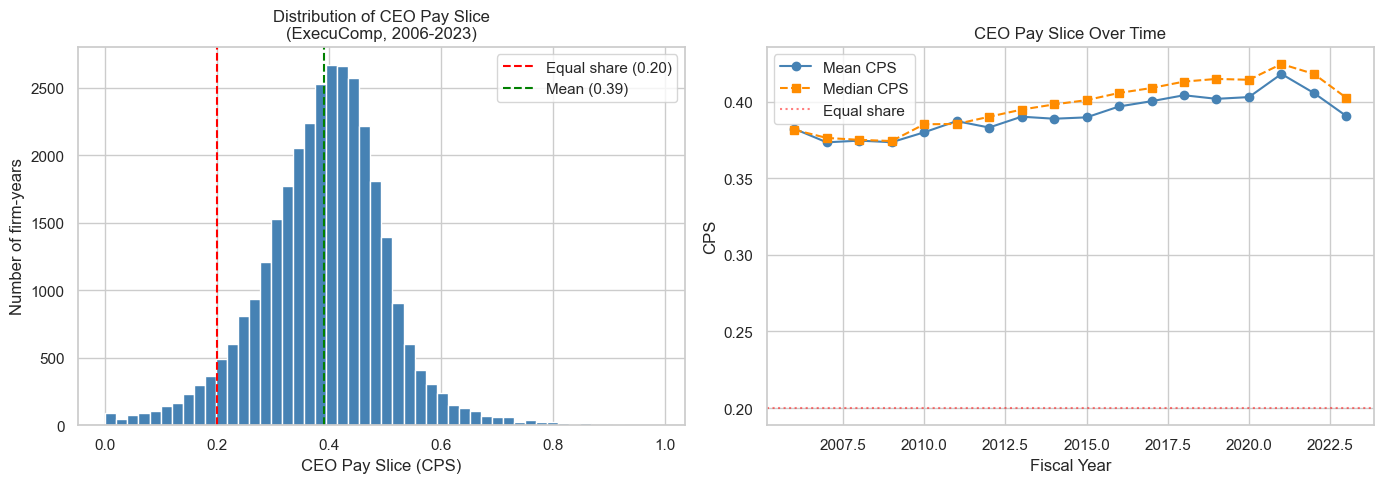

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of CPS
axes[0].hist(cps["cps"], bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(0.20, color="red", linestyle="--", label="Equal share (0.20)")
axes[0].axvline(cps["cps"].mean(), color="green", linestyle="--",
                label=f"Mean ({cps['cps'].mean():.2f})")
axes[0].set_title("Distribution of CEO Pay Slice\n(ExecuComp, 2006-2023)")
axes[0].set_xlabel("CEO Pay Slice (CPS)")
axes[0].set_ylabel("Number of firm-years")
axes[0].legend()

# Mean and median CPS over time
yearly = cps.groupby("year")["cps"].agg(["mean", "median"])
axes[1].plot(yearly.index, yearly["mean"], "o-", color="steelblue", label="Mean CPS")
axes[1].plot(yearly.index, yearly["median"], "s--", color="darkorange", label="Median CPS")
axes[1].axhline(0.20, color="red", linestyle=":", alpha=0.5, label="Equal share")
axes[1].set_title("CEO Pay Slice Over Time")
axes[1].set_xlabel("Fiscal Year")
axes[1].set_ylabel("CPS")
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
# Top 10 highest-CPS firm-years in the sample
top_cps = cps.nlargest(10, "cps")[["company", "ceo_name", "year", "ceo_comp", "top5_total_comp", "cps"]]
top_cps["ceo_comp"] = top_cps["ceo_comp"].apply(lambda x: f"${x:,.0f}")
top_cps["top5_total_comp"] = top_cps["top5_total_comp"].apply(lambda x: f"${x:,.0f}")
top_cps["cps"] = top_cps["cps"].apply(lambda x: f"{x:.2%}")
print("Top 10 Highest CEO Pay Slices in the Sample:\n")
print(top_cps.to_string(index=False))

Top 10 Highest CEO Pay Slices in the Sample:

               company            ceo_name    year ceo_comp top5_total_comp    cps
         PINTEREST INC    William J. Ready  2022.0 $122,652        $124,299 98.68%
   AXON ENTERPRISE INC    Patrick W. Smith  2018.0 $246,027        $249,908 98.45%
     VEEVA SYSTEMS INC    Peter P. Gassner  2017.0  $88,143         $90,411 97.49%
           MASIMO CORP     Joseph E. Kiani  2015.0 $119,223        $122,768 97.11%
        TRADE DESK INC Jeffrey Terry Green  2021.0 $834,969        $863,958 96.64%
              COTY INC         Sue Y. Nabi  2021.0 $283,791        $295,567 96.02%
ICONIX BRAND GROUP INC           Neil Cole  2008.0  $32,453         $34,117 95.12%
             TESLA INC        Elon R. Musk  2012.0  $78,150         $82,329 94.92%
     EXPEDIA GROUP INC  Peter Maxwell Kern  2021.0 $296,248        $317,622 93.27%
                    RH    Gary G. Friedman  2020.0 $178,008        $194,258 91.63%


## 6. Comparing to Bebchuk, Cremers & Peyer (2011): What's the same, what's different

**What replicates cleanly**

The CPS construction maps perfectly onto ExecuComp. The `tdc1` field and the `ceoann` flag are exactly the variables the authors use, and the `anncomp` table provides all the information needed in a single query. The mean CPS in our sample should be in the neighborhood of 0.35 to 0.40, consistent with the paper's findings. The time trend should show a gradual increase in CPS over the past two decades, reflecting the well-documented growth in CEO pay relative to other executives.

**Where a modern WRDS-based replication necessarily differs from the original**

1. **Sample period.** Bebchuk et al. use 1993 to 2008. Our sample starts from 2006, which means we cover different economic regimes (including post-financial-crisis changes to executive compensation like say-on-pay requirements under Dodd-Frank). The level of CPS may differ as compensation practices have evolved.

2. **Firm value regressions.** The paper's main contribution is showing that CPS is negatively associated with industry-adjusted Tobin's Q. This requires merging ExecuComp with Compustat to get firm-level financial data (`at`, `mkvalt`, `ceq`). We focus on constructing and visualizing CPS itself, but the valuation regression is a natural extension students can build by joining on `gvkey` and `year`.

3. **Compensation definition.** The paper uses `tdc1` throughout, which is the standard measure. However, S&P has revised the calculation of `tdc1` over time, particularly after the 2006 SEC disclosure rule changes (which altered how option awards are valued). Our post-2006 sample uses the revised calculation consistently, while the original paper spans both the old and new regimes.

4. **ExecuComp coverage.** ExecuComp covers S&P 1500 firms, so results may not generalize to smaller or private companies. The original paper also restricts to S&P 1500 firms, so this is actually a feature rather than a limitation.

---

## References
- [Bebchuk, L. A., Cremers, K. J. M. & Peyer, U. C. (2011). The CEO Pay Slice. *Journal of Financial Economics*, 102(1), 199–221.](https://doi.org/10.1016/j.jfineco.2011.05.006)
- WRDS ExecuComp guide: https://uufinance.github.io/data/wrds/databases/execucomp/
- WRDS ExecuComp access page: https://wrds-www.wharton.upenn.edu/pages/get-data/compustat-capital-iq-standard-poors/compustat/execucomp/
- WRDS Python/API setup guide: https://uufinance.github.io/data/wrds/notebook/

*Prepared for the U.S.E. Finance Data Hub as a database-tutorial template.*
